# Computing Distances on the Tropical Jacobian

Yueqi Cao, *Department of Mathematics, Imperial College London*

Email: y.cao21@imperial.ac.uk

The tropical Jacobian is naturally associated with compatible metrics. However, the computation of distances on the tropical Jacobian is equivalent to the Closest Vector Problem (CVP) in cryptology, which is known to be NP-hard. In this notebook we will introduce the computation and approximation of tropical distances, with the help of available open source CVP solvers and Mixed Integer Programming (MIP) solvers.

In [1]:
import sys
from pathlib import Path

src_path = Path("../src") 
sys.path.append(str(src_path))

import mgraph
from tropdist import *
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# set random seed for reproducibility
np.random.seed(0)

## The Tropical Jacobian

For a metric graph $G$, its tropical Jacobian is $\mathrm{Jac}(G)=(\Omega^*(G)/H_1(G;\mathbb{Z}),P)$ where $P$ is a canonically defined inner product on $\Omega^*(G)$, known as the *tropical polarization*. With this inner product the tropical Jacobian is a Riemannian manifold with flat metric. In the computation of tropical Abel--Jacobi transform, we explicitly fixed an isometry $\mathrm{Jac}(G)\cong (\mathbb{R}^g/L,P)$ where the lattice $L$ is generated by the column vectors of the tropical period matrix $Q$ and the tropical polarization represented by the matrix $Q^{-1}$.

Firstly Let's go over the computation of the tropical Abel--Jacobi transform.

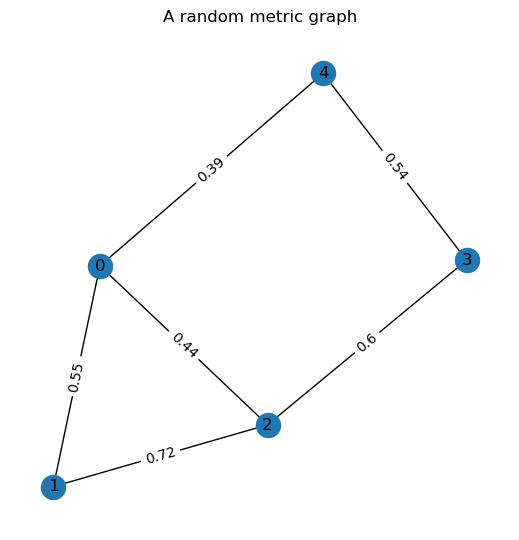

In [2]:
# Create a random metric graph
num_nodes = 5
g = 2 # set dimension=2 for illustration
MG = generate_random_graph(num_nodes, max_edges=num_nodes+g-1)

# draw the random graph
plt.figure(figsize=(5,5))
pos = nx.spring_layout(MG)
nx.draw(MG, pos, with_labels=True)   
edge_labels = nx.get_edge_attributes(MG,'weight') 
edge_dic = nx.draw_networkx_edge_labels(MG, pos, edge_labels=edge_labels)
plt.title("A random metric graph")
plt.show()

In [6]:
# compute the tropical Abel--Jacobi transform

# compute a minimal spanning tree
MST = nx.minimum_spanning_tree(MG)
# set the base point of the transform
base_point = list(MST.nodes())[0]
# compute the transform
V0 = MG.trop_transform(MST, base_point)
# sample more points from the transform
V = MG.interpolate(MST, V0, 3)
# compute the tropical polarization matrix
Q = MG.trop_period(MST)
print("the tropical period matrix is\n", Q)

the tropical period matrix is
 [[1.71 0.44]
 [0.44 1.97]]


We can translate all points to the fundamental domain of $\mathrm{Jac}(G)$ spanned by the column vectors of the tropical period matrix $Q$.

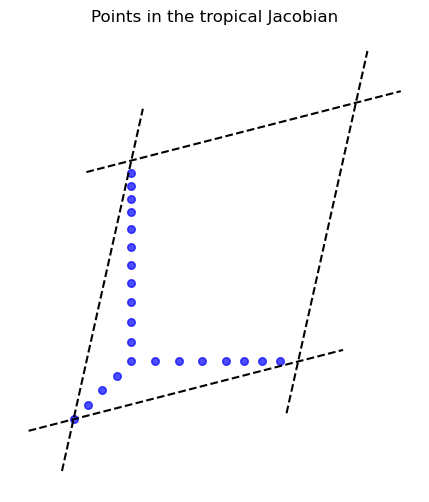

In [8]:
# draw the tropical Abel--Jacobi transform
fig, ax = plt.subplots(figsize=(6,6))
draw_lattice_2D(Q, ax)
# translate the vectors for better visualization
# the dotted lines depict the fundamental domain
Vr = translate_to_fundamental_domain(V, Q)
ax.scatter(Vr[0,:], Vr[1,:], color='blue', s=30, alpha=0.7)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title("Points in the tropical Jacobian")
plt.show()

The lattice basis given by $Q$ may not be a ''good'' basis for further computations of distances. The goodness of a basis can be improved via *LLL-reduction*. Roughly speaking, an LLL-reduced basis is as orthogonal as possible. We use the ```fplll``` library to compute the LLL-reduction of a lattice basis.

Is Q_LLL reduced?  True
The reduced lattice is 
 [[ 1.71 -1.27]
 [ 0.44  1.53]]


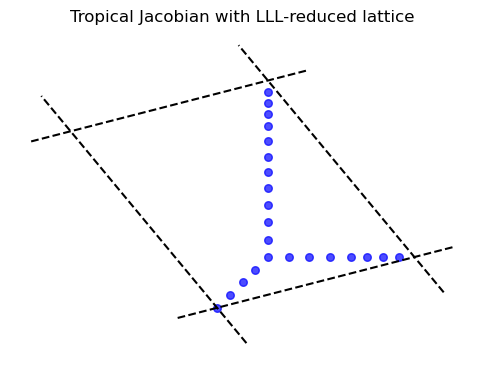

In [9]:
# compute the LLL-reduced lattice
Q_check, Q_LLL = LLL_reduced_lattice(Q)

# check if Q_LLL is indeed LLL-reduced
print("Is Q_LLL reduced? ", fp.LLL.is_reduced(Q_check))
print("The reduced lattice is \n", Q_LLL)

# draw the LLL-reduced lattice and points
fig, ax = plt.subplots(figsize=(6,6))
draw_lattice_2D(Q_LLL, ax)
Vr = translate_to_fundamental_domain(V, Q_LLL)
ax.scatter(Vr[0,:], Vr[1,:], color='blue', s=30, alpha=0.7)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title("Tropical Jacobian with LLL-reduced lattice")
plt.show()

In the above example, the LLL-reduced basis does not look ''orthogonal'', which contradicts to our prediction. Why? The reason is that the LLL-reduction is performed for the standard $L^2$ norm, whereas in our case the inner product is represented by $Q^{-1}$. Therefore we need to apply an isometry first to change the inner product to the standard one. 

## Computation of Tropical Polarization Distances

The distance function induced from tropical polarization is
$$
d_{trop}([x],[y])=\min_{n\in\mathbb{N}^g}(x-y-Qn)^\top Q^{-1}(x-y-Qn)
$$
First we apply the linear transformation by $Q^{-1/2}$ so that
$$
d_{trop}([x'],[y'])=\min_{n\in\mathbb{N}^g}\|x'-y'-Q^{1/2}n\|_2^2
$$
Then we can apply the LLL-reduction algorithm to $Q^{1/2}$. After that we use the enumeration methods in ```fplll``` or sieving methods in ```G6K``` to compute the closest lattice vector to $x'-y'$, which at the same time gives the distance.

The lattice for L_2 metric is
 [[1.29741  0.163482]
 [0.163482 1.394013]]


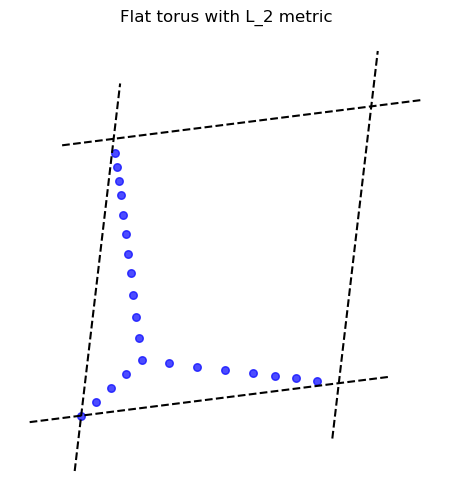

In [10]:
# transform the tropical Jacobian to a standard flat torus with the L_2 metric
V_L2, Q_sqrt = to_L2(V, Q)

# the lattice basis is given by Q_sqrt, apply the LLL-reduction to Q_sqrt
# due to the requirement of fpylll, Q_sqrt_check is scaled and transposed over Q_sqrt_LLL
Q_sqrt_check, Q_sqrt_LLL = LLL_reduced_lattice(Q_sqrt)
print("The lattice for L_2 metric is\n", Q_sqrt_LLL)

# draw the LLL-reduced lattice and points
fig, ax = plt.subplots(figsize=(6,6))
draw_lattice_2D(Q_sqrt_LLL, ax)
Vr = translate_to_fundamental_domain(V_L2, Q_sqrt_LLL)
ax.scatter(Vr[0,:], Vr[1,:], color='blue', s=30, alpha=0.7)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title("Flat torus with L_2 metric")
plt.show()

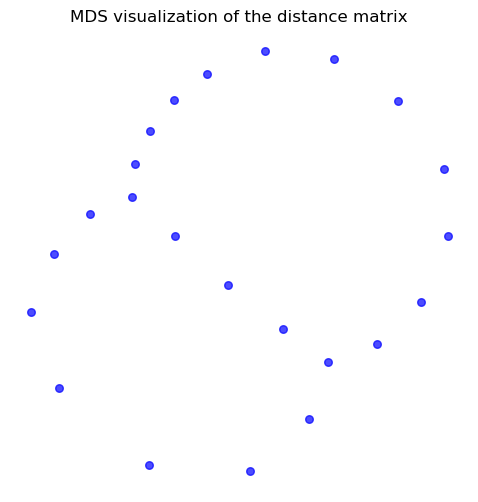

In [12]:
# compute the exact tropical polarization distance matrix

dist_exact = exact_L2_distance(V_L2, Q_sqrt)

# visualize the distance matrix using MDS
from sklearn.manifold import MDS
embedding = MDS(n_components=2, dissimilarity='precomputed')
X = embedding.fit_transform(dist_exact)
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(X[:,0], X[:,1], color='blue', s=30, alpha=0.7)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title("MDS visualization of the distance matrix")
plt.show()

## Fast Computation of Truncated Tropical Polarization Distances

The computational complexity of CVP is known to be NP-hard with respect to the dimension of a torus. For metric graphs with small genus, exact computation of tropical polarization distance is still possible. However, for graphs with large genus, it is not feasible to obtain the full distance matrix with an accurate error bound. We can make a trade-off by maintaining small distances (i.e. distances within a small neighborhood) and applying much faster approximation algorithms called Babai's algorithms. 

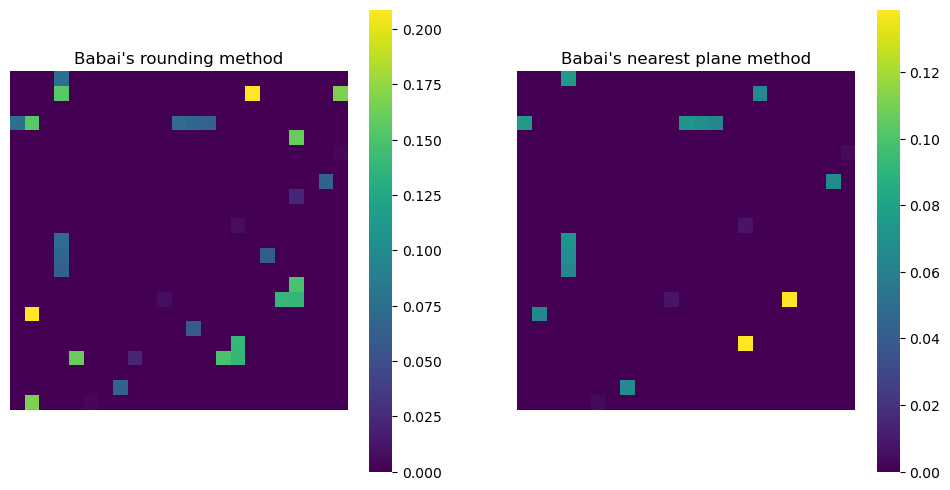

In [13]:
# Babai's algorithms to compute the closest point in the lattice

# Babai's rounding algorithm
dist_round = babai_rounding(V_L2, Q_sqrt_LLL)

# Babai's nearest plane algorithm
dist_nearest = babai_nearest_plane_original(V_L2, Q_sqrt_LLL)


# visualize the approximation errors
import seaborn as sns

error_round = np.abs(dist_exact - dist_round)
error_nearest = np.abs(dist_exact - dist_nearest)


fig, ax = plt.subplots(1, 2, figsize=(12,6))

sns.heatmap(error_round, ax=ax[0], cmap='viridis', fmt='.2f')
ax[0].set_aspect('equal')
ax[0].axis("off")
ax[0].set_title("Babai's rounding method")

sns.heatmap(error_nearest, ax=ax[1], cmap='viridis', fmt='.2f')
ax[1].set_aspect('equal')
ax[1].axis("off")
ax[1].set_title("Babai's nearest plane method")

plt.show()


In [14]:
# thresholding for the approximate distance matrix
threshold = 0.2
local_dist_mat = truncate_mat(dist_nearest, threshold)

error = np.abs(dist_exact - local_dist_mat)
error[np.isinf(error)] = 0
print("the approximation error for local distances is:", np.sqrt(np.sum(error**2)))

the approximation error for local distances is: 1.8169830447432734e-06


## Computation of Foster--Zhang Distances

Another compatible metric on the tropical Jacobian is the *Foster--Zhang* metric. To explain, consider an equivalent definition of the tropical Abel--Jacobi map: since the tropical polarization comes from the inner product on the 1-chain space $C_1(G;\mathbb{R})$ with $(e_i,e_j)=\delta_{ij}\ell(e_i)$, the tropical Abel--Jacobi map can be equivalently defined via the orthogonal projection $C_1(G;\mathbb{R})\to H_1(G;\mathbb{R})$. The Foster--Zhang metric is induced from $L^\infty$ norm on $C_1(G;\mathbb{R})$. Optimization with the $L^\infty$ norm can be reformulated as a linear programming problem. As $n\in\mathbb{N}^g$ is an integer vector, the LP problem has integer variables, making it an mixed integer LP (MILP) problem. There are many available MIP solvers in the literature. In the following we present a computation using the interface ```pyomo``` and the solver ```cbc```. 

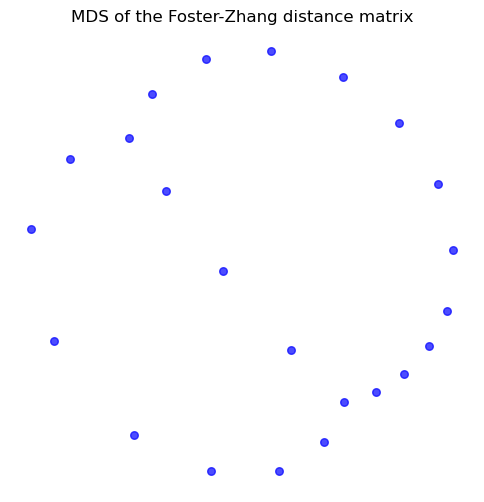

In [15]:
# computation using pyomo and cbc solver

# compute the cycle--edge incidence matrix
C = MG.cycle_edge(MST)
dist_FS = FS_distance(C, V, Q)

# visualize the distance matrix using MDS
embedding = MDS(n_components=2, dissimilarity='precomputed')
X = embedding.fit_transform(dist_FS)
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(X[:,0], X[:,1], color='blue', s=30, alpha=0.7)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title("MDS of the Foster-Zhang distance matrix")
plt.show()